# 15 — A Two-Layer Network on CIFAR-10

This notebook applies the reusable `TwoLayerNet` to real images. The goal is the experimental workflow, not state-of-the-art accuracy.

## Learning objectives

- prepare train, validation, and test data without leakage;
- verify the network by overfitting a tiny subset;
- compare a small number of hyperparameter configurations;
- use validation accuracy for selection;
- retrain after selection and evaluate the test set once;
- interpret learning curves and remaining limitations.

The default experiment uses only 6,000 training images for manageable runtime.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

from cs231n_practice.classifiers.neural_net import TwoLayerNet

SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)


## 1. Prepare the data

We use this protocol:

```text
official training set
└── reproducible 6,000-example development subset
    ├── 5,000 training examples
    └── 1,000 validation examples

official test set
└── untouched until model selection is finished
```

Images are flattened to 3,072 features and scaled to $[0,1]$. The feature mean must be fitted on training data only and then applied to validation data.

For final retraining, we will fit a new mean on all 6,000 development examples and apply it to the test set.


### Exercise 1 — Build the training and validation arrays

Select development indices before converting to floating point. This avoids materializing all 50,000 flattened images as a large float array.


In [4]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

DEVELOPMENT_SIZE = 6_000
TRAIN_SIZE = 5_000
split_generator = np.random.default_rng(SEED)
development_indices = split_generator.permutation(
    len(train_dataset.data)
)[:DEVELOPMENT_SIZE]

# Select, flatten, convert to float32, and scale development images.
X_development_raw = train_dataset.data[development_indices].reshape(DEVELOPMENT_SIZE, -1).astype(np.float32) / 255.0
y_development = np.asarray(train_dataset.targets, dtype=np.int64)[development_indices]

X_train_raw = X_development_raw[:TRAIN_SIZE]
y_train = y_development[:TRAIN_SIZE]
X_validation_raw = X_development_raw[TRAIN_SIZE:]
y_validation = y_development[TRAIN_SIZE:]

# Fit this mean using only X_train_raw.
training_mean = X_train_raw.mean(axis=0, keepdims=True)
X_train = X_train_raw - training_mean
X_validation = X_validation_raw - training_mean

assert X_train.shape == (5_000, 3_072)
assert X_validation.shape == (1_000, 3_072)
assert y_train.shape == (5_000,)
assert y_validation.shape == (1_000,)
assert training_mean.shape == (1, 3_072)
assert np.allclose(X_train.mean(axis=0), 0.0, atol=1e-5)
print(X_train.shape, X_validation.shape)


(5000, 3072) (1000, 3072)


## 2. First diagnostic: overfit a tiny subset

Before a full experiment, ask whether the implementation can memorize a very small dataset. Failure to overfit often reveals a bug, unsuitable learning rate, or unsuitable initialization.

This is a debugging test, not evidence of generalization.


### Exercise 2 — Overfit 50 examples

Train for 500 iterations with learning rate $0.5$, no regularization, and the complete tiny subset as one batch. Plot loss and report training accuracy. If accuracy remains low, inspect the curve before changing many settings at once.


Tiny-subset accuracy: 1.0


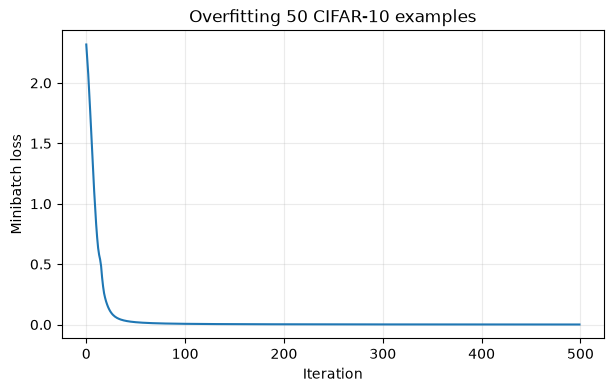

In [17]:
TINY_SIZE = 50
X_tiny = X_train[:TINY_SIZE]
y_tiny = y_train[:TINY_SIZE]

tiny_model = TwoLayerNet(
    input_dim=X_train.shape[1],
    hidden_dim=100,
    num_classes=10,
    weight_scale=np.sqrt(2.0 / X_train.shape[1]),
    seed=SEED + 1,
)

tiny_loss_history = tiny_model.train(
    X_tiny,
    y_tiny,
    learning_rate=0.5,
    num_iterations=500,
    batch_size=50,
)
tiny_accuracy = np.mean(tiny_model.predict(X_tiny) == y_tiny)

print("Tiny-subset accuracy:", tiny_accuracy)
assert tiny_loss_history[-20:].mean() < tiny_loss_history[:20].mean()
assert tiny_accuracy > 0.90

plt.figure(figsize=(7, 4))
plt.plot(tiny_loss_history)
plt.xlabel("Iteration")
plt.ylabel("Minibatch loss")
plt.title("Overfitting 50 CIFAR-10 examples")
plt.grid(alpha=0.25)
plt.show()


## 3. Small validation search

We will compare only four configurations. Each model uses the same train/validation split and initialization seed. Hidden size changes model capacity; learning rate changes optimization; regularization changes the objective.

The numeric learning rates of different optimizers would not be directly interchangeable, but all models here use vanilla SGD.


In [12]:
configurations = [
    {"hidden_dim": 32, "learning_rate": 0.05, "regularization_strength": 1e-4},
    {"hidden_dim": 32, "learning_rate": 0.10, "regularization_strength": 1e-4},
    {"hidden_dim": 64, "learning_rate": 0.05, "regularization_strength": 1e-3},
    {"hidden_dim": 64, "learning_rate": 0.10, "regularization_strength": 1e-3},
]
SEARCH_ITERATIONS = 300


### Exercise 3 — Train and compare configurations

For each configuration:

1. create a fresh model;
2. train only on `X_train, y_train`;
3. train for `SEARCH_ITERATIONS` with batch size `128`, weight scale $\sqrt{2/D}$, and seed `SEED + 10`;
4. measure training and validation accuracy;
5. store the model, loss history, configuration, and metrics.

Select by validation accuracy—not training accuracy or final minibatch loss.


{'hidden_dim': 32, 'learning_rate': 0.05, 'regularization_strength': 0.0001} train= 0.318 validation= 0.294
{'hidden_dim': 32, 'learning_rate': 0.1, 'regularization_strength': 0.0001} train= 0.393 validation= 0.352
{'hidden_dim': 64, 'learning_rate': 0.05, 'regularization_strength': 0.001} train= 0.349 validation= 0.344
{'hidden_dim': 64, 'learning_rate': 0.1, 'regularization_strength': 0.001} train= 0.414 validation= 0.387
Selected: {'hidden_dim': 64, 'learning_rate': 0.1, 'regularization_strength': 0.001}


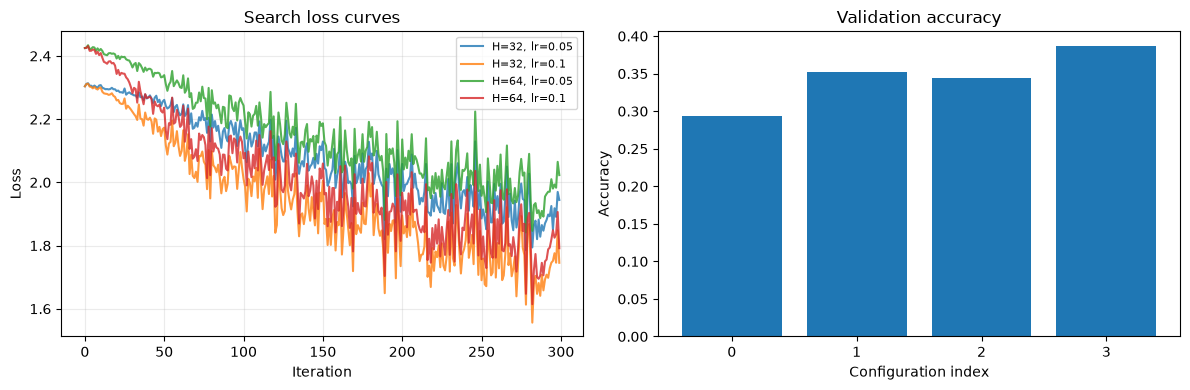

In [18]:
search_results = []

for configuration in configurations:
    model = TwoLayerNet(
        input_dim=X_train.shape[1],
        hidden_dim=configuration["hidden_dim"],
        num_classes=10,
        weight_scale=np.sqrt(2.0 / X_train.shape[1]),
        seed=SEED + 10,
    )
    loss_history = model.train(
        X_train,
        y_train,
        batch_size=128,
        num_iterations=SEARCH_ITERATIONS,
        learning_rate=configuration["learning_rate"],
        regularization_strength=configuration["regularization_strength"],
        seed=SEED + 10,
    )

    training_accuracy = np.mean(model.predict(X_train) == y_train)
    validation_accuracy = np.mean(model.predict(X_validation) == y_validation)

    result = {
        "configuration": configuration,
        "model": model,
        "loss_history": loss_history,
        "training_accuracy": training_accuracy,
        "validation_accuracy": validation_accuracy,
    }
    search_results.append(result)
    print(
        configuration,
        "train=", f"{result['training_accuracy']:.3f}",
        "validation=", f"{result['validation_accuracy']:.3f}",
    )

assert len(search_results) == len(configurations)
selected_result = max(
    search_results,
    key=lambda result: result["validation_accuracy"],
)
selected_configuration = selected_result["configuration"]
print("Selected:", selected_configuration)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for result in search_results:
    label = (
        f"H={result['configuration']['hidden_dim']}, "
        f"lr={result['configuration']['learning_rate']}"
    )
    axes[0].plot(result["loss_history"], alpha=0.8, label=label)
axes[0].set(title="Search loss curves", xlabel="Iteration", ylabel="Loss")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].bar(
    np.arange(len(search_results)),
    [result["validation_accuracy"] for result in search_results],
)
axes[1].set(
    title="Validation accuracy",
    xlabel="Configuration index",
    ylabel="Accuracy",
    xticks=np.arange(len(search_results)),
)
plt.tight_layout()
plt.show()


## 4. Retrain, then evaluate the test set once

Selection is now complete. Refit preprocessing on all development examples, retrain a fresh model using the selected hyperparameters, and only then evaluate the official test set.

The test result estimates performance of this complete procedure. It must not be used to return to the search and choose another configuration.


### Exercise 4 — Final retraining and test evaluation

Use all 6,000 development examples, 600 iterations, batch size `128`, weight scale $\sqrt{2/D}$, and seed `SEED + 20`. The complete test set is used only for this final measurement.


Development accuracy: 0.5001666666666666
Final test accuracy: 0.426


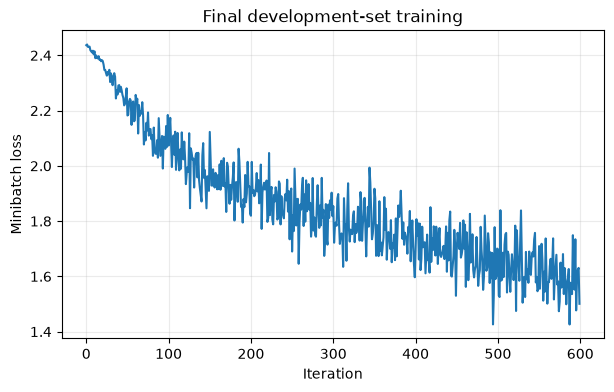

In [19]:
# Fit final preprocessing on all development examples.
final_mean = X_development_raw.mean(axis=0, keepdims=True)
X_development = X_development_raw - final_mean
X_test_raw = test_dataset.data.reshape(-1, 32 * 32 * 3).astype(np.float32) / 255.0
y_test = np.asarray(test_dataset.targets, dtype=np.int64)
X_test = X_test_raw - final_mean

final_model = TwoLayerNet(
    input_dim=X_development.shape[1],
    hidden_dim=selected_configuration["hidden_dim"],
    num_classes=10,
    weight_scale=np.sqrt(2.0 / X_development.shape[1]),
    seed=SEED + 20,
)
final_loss_history = final_model.train(
    X_development,
    y_development,
    batch_size=128,
    num_iterations=600,
    learning_rate=selected_configuration["learning_rate"],
    regularization_strength=selected_configuration["regularization_strength"],
    seed=SEED + 20,
)

development_accuracy = np.mean(final_model.predict(X_development) == y_development)
test_accuracy = np.mean(final_model.predict(X_test) == y_test)

print("Development accuracy:", development_accuracy)
print("Final test accuracy:", test_accuracy)

assert X_test.shape == (10_000, 3_072)
assert 0.0 <= test_accuracy <= 1.0

plt.figure(figsize=(7, 4))
plt.plot(final_loss_history)
plt.xlabel("Iteration")
plt.ylabel("Minibatch loss")
plt.title("Final development-set training")
plt.grid(alpha=0.25)
plt.show()


## 5. Inspect predictions and mistakes

This visualization adds no new training logic. It shows ten correct and ten incorrect test predictions.


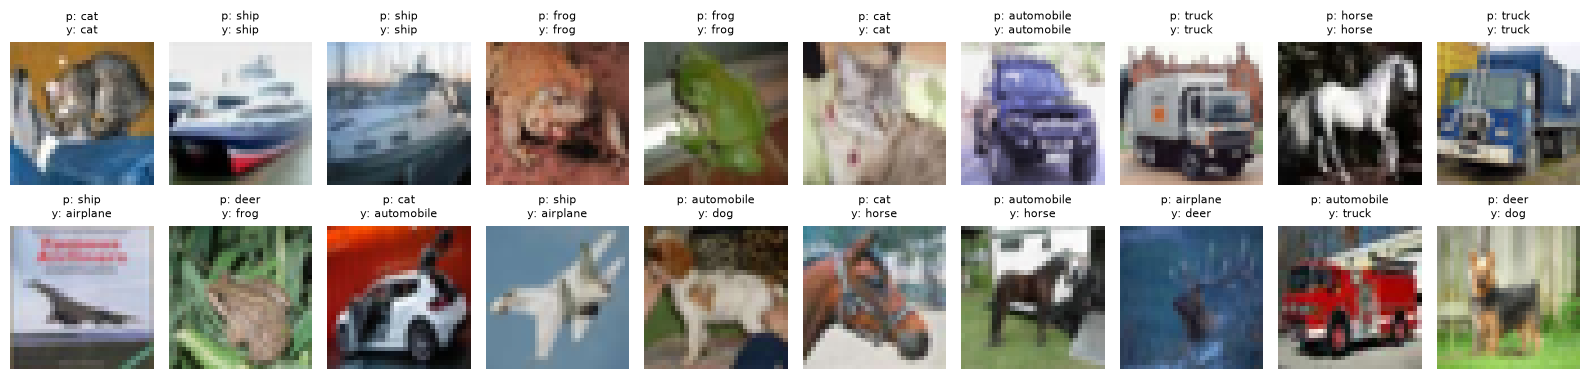

In [20]:
test_predictions = final_model.predict(X_test)
correct_indices = np.flatnonzero(test_predictions == y_test)[:10]
incorrect_indices = np.flatnonzero(test_predictions != y_test)[:10]
display_indices = np.concatenate([correct_indices, incorrect_indices])

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for axis, index in zip(axes.ravel(), display_indices):
    axis.imshow(test_dataset.data[index])
    predicted = CLASS_NAMES[test_predictions[index]]
    actual = CLASS_NAMES[y_test[index]]
    axis.set_title(f"p: {predicted}\ny: {actual}", fontsize=8)
    axis.axis("off")
axes[0, 0].set_ylabel("Correct")
axes[1, 0].set_ylabel("Mistakes")
plt.tight_layout()
plt.show()


## Reflection

Add a Markdown cell answering:

1. Why was the feature mean fitted only on training data during search?
2. What does successfully overfitting 50 examples tell us?
3. What would failure to overfit the tiny subset suggest?
4. Why can training accuracy not select a configuration?
5. What different roles do hidden size, learning rate, and regularization play?
6. Why must every configuration start from a fresh model?
7. What patterns in a loss curve suggest a learning rate is too small or too large?
8. Why was preprocessing refitted on all development data before final training?
9. Why must final test accuracy not influence another selection round?
10. Why might this two-layer raw-pixel model still perform poorly on CIFAR-10?
11. What limitations does this small search have?
12. What did the inspected mistakes reveal?

This completes the first affine-ReLU neural-network workflow. The next step is to review the roadmap and decide whether to deepen optimization experiments or proceed to richer neural-network architectures.


1. The mean was fitted only on training data so validation examples could not influence preprocessing. Otherwise validation information would leak into model selection.
2. Successfully overfitting 50 examples shows that the model has enough capacity and that the forward pass, gradients, and optimizer can fit a small dataset.
3. Failure could suggest an implementation bug, incorrect gradients, an unsuitable learning rate, poor initialization, excessive regularization, or insufficient model capacity.
4. Training accuracy measures fit to data used for parameter learning. It generally favors greater capacity and cannot estimate performance on unseen examples. Hyperparameters must be selected using validation data.
5. Hidden size controls model capacity. Learning rate controls update size and optimization behavior. Regularization penalizes large weights and controls the trade-off between fitting and model complexity.
6. Every configuration needs a fresh model so it starts from the same stage of training. Reusing a previously trained model would give later configurations an unfair advantage and mix the effects of different hyperparameters.
7. A very small learning rate usually produces a slow, smooth decrease. A very large rate can cause strong oscillation, unstable growth, NaN values, or failure to decrease.
8. Once selection was finished, the validation examples no longer needed to remain separate. Refitting preprocessing and training on all development data allowed the final model to use all 6,000 available development examples.
9. If test accuracy influences another model choice, the test set becomes part of model selection. Its reported accuracy would then be optimistically biased rather than an independent final estimate.
10. Flattening removes spatial structure. The model does not explicitly exploit local patterns, translation, edges, textures, or hierarchical image features as convolutional networks do.
11. The search contains only four coupled configurations, one split, one initialization per configuration, one minibatch sequence, short training budgets, and fixed batch size and initialization scale. Because hidden size and regularization change together, their individual effects cannot be isolated.
12. The mistakes likely include visually similar classes and objects whose identity depends on spatial or contextual details. They illustrate the limitations of a shallow fully connected model operating on flattened raw pixels.